# Attack-as-Design — reproducible pipeline (TF-Bind-8)

This single notebook reproduces the core loop of the paper
**"Attack-as-Design: Turning Surrogate Exploitation into Validated Biological Sequence Design."**

**The pipeline, end to end:**

1. **sequence → features** — one-hot or 4-mer counts
2. **train a surrogate** — a small model that predicts a property (here: transcription-factor binding) from the features
3. **GA attack** — a genetic algorithm iterates over the sequence space to maximise the *surrogate's* predicted property (this is the same search that produces adversarial examples)
4. **independent verification** — the seed and the optimised design are scored by verifiers the surrogate/GA never used:
   * the **exact oracle** (ground truth — the complete measured binding landscape of all 65,536 8-mers), and
   * a **held-out surrogate** trained on a disjoint split.

**Why TF-Bind-8?** It is the single dataset where the verifier is *exact*, not a proxy: every 8-base-pair DNA sequence (4⁸ = 65,536 of them) has a measured binding score (Barrera et al., *Science* 2016). The surrogate sees only a subset, so looking up the true score is a genuinely independent check. Everything here is pure NumPy + scikit-learn: **no GPU, no downloads beyond one 256 KB file; every cell runs in about ten seconds.**


> **What this notebook reproduces.** This is a clean, dependency-free reproduction of the *mechanism* — sequence → surrogate → attack → independent verification — not a bit-for-bit re-run of the paper's baseline table. The one quantity that should agree does: the one-hot surrogate reaches test Spearman ≈ 0.77 here versus **0.765** reported in the paper. The exact design sequences and the per-method true-top-16 numbers in the paper differ from this notebook on purpose, because the paper's TF-Bind-8 baseline table uses the **DNABERT-2** surrogate (test ρ ≈ 0.52), the fixed dataset split, a matched 5000-query budget over 5 seeds, and reports *true top-16*; this notebook uses a one-hot/4-mer surrogate, a 50/20/30 split, 30 GA generations, and reports the true-oracle gain of the best design. Same story, cleaner setup.


## 0. Setup

In [1]:
# Needs only numpy, scipy, scikit-learn, matplotlib (all standard).
SEED = 0

import numpy as np, json, time, urllib.request, os
from itertools import product
from scipy.stats import spearmanr
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

rng = np.random.default_rng(SEED)
BASES = "ACGT"; B2I = {b:i for i,b in enumerate(BASES)}
MERS  = ["".join(p) for p in product("ACGT", repeat=8)]   # all 65,536 8-mers, fixed order
M2I   = {m:i for i,m in enumerate(MERS)}
print(f"{len(MERS):,} possible 8-mers")

65,536 possible 8-mers


## 1. Load the data (the exact binding oracle)

`y_SIX6.npy` holds the measured, normalised binding affinity (0–1) of the SIX6 transcription factor
for **all 65,536 8-mers**, indexed in the fixed `ACGT` enumeration order above. This array *is* the
ground-truth oracle. It is ~256 KB; the cell falls back to downloading it from the paper's repository
if it is not present locally.

In [2]:
Y_PATH = "y_SIX6.npy"
URL = "https://raw.githubusercontent.com/armandyam/attack-as-design/main/notebook/y_SIX6.npy"
if not os.path.exists(Y_PATH):
    print("downloading oracle ...")
    urllib.request.urlretrieve(URL, Y_PATH)
Y = np.load(Y_PATH).astype(np.float64)          # true binding, MERS order
assert Y.shape == (65536,), Y.shape
def oracle(seqs):                                # the independent ground-truth verifier
    return np.array([Y[M2I[s]] for s in seqs])
print(f"oracle loaded: {Y.shape[0]:,} sequences, range [{Y.min():.3f}, {Y.max():.3f}], mean {Y.mean():.3f}")

oracle loaded: 65,536 sequences, range [0.000, 1.000], mean 0.464


## 2. Featurizers: sequence → numbers

Two ways to turn an 8-base sequence into a feature vector, both pure NumPy. This featurization is a
**swappable choice** — the surrogate, attack and verification steps below do not care which one is used.

In [3]:
def feat_onehot(seqs):
    X = np.zeros((len(seqs), 32), np.float32)          # 8 positions x 4 bases
    for i, s in enumerate(seqs):
        for j, c in enumerate(s): X[i, j*4 + B2I[c]] = 1.0
    return X

KMERS4 = ["".join(p) for p in product("ACGT", repeat=4)]; K2I = {k:i for i,k in enumerate(KMERS4)}
def feat_kmer4(seqs):
    X = np.zeros((len(seqs), 256), np.float32)         # counts of each 4-mer
    for i, s in enumerate(seqs):
        for w in range(len(s)-3): X[i, K2I[s[w:w+4]]] += 1.0
    return X

FEATURIZERS = {"onehot": feat_onehot, "kmer4": feat_kmer4}

## 3. Train the surrogate

Split the 65,536 sequences into **train / test / held-out** (disjoint). Train a small multilayer
perceptron to predict binding from the chosen features. Report the rank correlation on the test set.

The **held-out** split is used later as a *second* independent verifier — a surrogate the attack never queries.

In [4]:
FEAT = "onehot"                                        # choose "onehot" or "kmer4"
featurize = FEATURIZERS[FEAT]

perm = np.random.default_rng(SEED).permutation(len(MERS))
n_tr, n_te = int(0.5*len(MERS)), int(0.2*len(MERS))
idx_tr, idx_te, idx_ho = perm[:n_tr], perm[n_tr:n_tr+n_te], perm[n_tr+n_te:]
seqs_tr = [MERS[i] for i in idx_tr]

t0 = time.time()
surrogate = MLPRegressor(hidden_layer_sizes=(128,64), max_iter=200, random_state=SEED)
surrogate.fit(featurize(seqs_tr), Y[idx_tr])
def surrogate_score(seqs): return surrogate.predict(featurize(seqs))

rho_te = spearmanr(surrogate_score([MERS[i] for i in idx_te]), Y[idx_te]).correlation
print(f"[{FEAT}] surrogate trained in {time.time()-t0:.1f}s  |  test Spearman = {rho_te:.3f}")

# held-out independent verifier (disjoint data, never queried by the attack)
verifier = MLPRegressor(hidden_layer_sizes=(128,64), max_iter=200, random_state=SEED+1)
verifier.fit(featurize([MERS[i] for i in idx_ho]), Y[idx_ho])
def verifier_score(seqs): return verifier.predict(featurize(seqs))
print(f"[{FEAT}] held-out verifier test Spearman = {spearmanr(verifier_score([MERS[i] for i in idx_te]), Y[idx_te]).correlation:.3f}")

[onehot] surrogate trained in 3.7s  |  test Spearman = 0.770
[onehot] held-out verifier test Spearman = 0.758


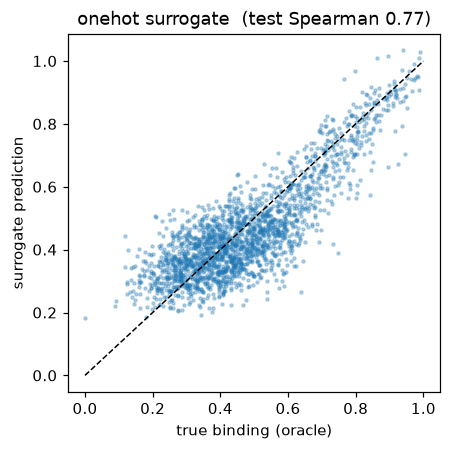

In [5]:
# surrogate calibration: predicted vs true on a sample of the test set
samp = np.random.default_rng(1).choice(idx_te, 2000, replace=False)
fig, ax = plt.subplots(figsize=(4.2,4.2))
ax.scatter(Y[samp], surrogate_score([MERS[i] for i in samp]), s=4, alpha=0.3)
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("true binding (oracle)"); ax.set_ylabel("surrogate prediction")
ax.set_title(f"{FEAT} surrogate  (test Spearman {rho_te:.2f})"); fig.tight_layout(); plt.show()

## 4. The GA attack (with iterations)

A genetic algorithm searches the 8-mer space to maximise the **surrogate's** predicted binding.
Each generation keeps the elite sequences, mutates them into children, and injects random immigrants.
This is exactly the search that finds adversarial examples of the surrogate.

An optional **biological constraint** `g(x)` — a GC-content band and a homopolymer-run cap derived only
from the training sequences (no extra model) — can be switched on to keep designs realistic. We track,
at every generation, both what the surrogate *believes* and what the sequence is *truly* worth.

In [6]:
def gc(s):  return (s.count("G")+s.count("C"))/8
def maxrun(s):
    m=c=1
    for i in range(1,8): c=c+1 if s[i]==s[i-1] else 1; m=max(m,c)
    return m
_gc = np.array([gc(s) for s in seqs_tr])
GC_LO, GC_HI = np.quantile(_gc,[0.01,0.99]); RUN_CAP = int(np.quantile([maxrun(s) for s in seqs_tr],0.99))
def plausible(s): return GC_LO <= gc(s) <= GC_HI and maxrun(s) <= RUN_CAP   # g(x): model-independent rule

def mutate(par, r, kmax=2):
    s=list(par); k=r.integers(1,kmax+1)
    for _ in range(k): p=r.integers(8); s[p]=BASES[r.integers(4)]
    return "".join(s)

def ga_attack(seed, r, constrained=False, pop=128, elite=16, gens=30, immig=0.25):
    population=[seed]+[mutate(seed,r) for _ in range(pop-1)]
    cache={}
    def sc(seqs):
        todo=[s for s in seqs if s not in cache]
        if todo:
            for s,v in zip(todo, surrogate_score(todo)): cache[s]=float(v)
        return np.array([cache[s] for s in seqs])
    traj=[]
    for g in range(gens):
        pv=sc(population)
        fit=pv.copy()
        if constrained:
            fit=np.array([pv[i] if plausible(population[i]) else -1e9 for i in range(len(population))])
        order=np.argsort(-fit)
        elites=[population[i] for i in order[:elite] if fit[i]>-1e8] or [population[order[0]]]
        n_imm=int(immig*pop)
        kids=[mutate(elites[r.integers(len(elites))],r) for _ in range(pop-len(elites)-n_imm)]
        imm=["".join(BASES[j] for j in r.integers(0,4,8)) for _ in range(n_imm)]
        population=elites+kids+imm
        cand=[s for s in population if (not constrained) or plausible(s)] or population
        best=cand[int(np.argmax(sc(cand)))]
        traj.append({"gen":g, "surrogate":cache[best], "true":float(Y[M2I[best]]), "design":best})
    return traj

## 5. Run the attack and verify against the oracle

In [7]:
# pick a mid-affinity starting sequence the surrogate has room to improve
mid = [i for i in idx_te if 0.40 <= Y[i] <= 0.50]
seed = MERS[np.random.default_rng(SEED).choice(mid)]
seed_true = float(Y[M2I[seed]])
print(f"seed = {seed}   true binding = {seed_true:.3f}   surrogate = {surrogate_score([seed])[0]:.3f}\n")

results={}
for tag, con in [("unconstrained", False), ("constrained g(x)", True)]:
    traj = ga_attack(seed, np.random.default_rng(SEED+7), constrained=con)
    d = traj[-1]
    results[tag]=traj
    print(f"{tag:18s}: design={d['design']}  surrogate={d['surrogate']:.3f}  "
          f"TRUE(oracle)={d['true']:.3f}  gain={d['true']-seed_true:+.3f}  "
          f"over-rating gap={d['surrogate']-d['true']:+.3f}  plausible={plausible(d['design'])}")

seed = TCGAGACC   true binding = 0.480   surrogate = 0.511

unconstrained     : design=AAGGTATC  surrogate=1.035  TRUE(oracle)=0.971  gain=+0.490  over-rating gap=+0.064  plausible=True
constrained g(x)  : design=AAGGTATC  surrogate=1.035  TRUE(oracle)=0.971  gain=+0.490  over-rating gap=+0.064  plausible=True


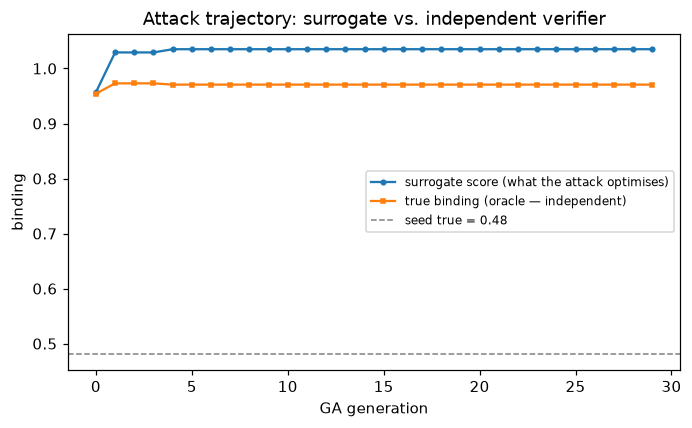

In [8]:
# trajectory: what the surrogate believes vs the true oracle value, per generation
fig, ax = plt.subplots(figsize=(6.4,4.0))
t = results["unconstrained"]
gens=[x["gen"] for x in t]
ax.plot(gens,[x["surrogate"] for x in t],"-o",ms=3,label="surrogate score (what the attack optimises)")
ax.plot(gens,[x["true"] for x in t],"-s",ms=3,label="true binding (oracle — independent)")
ax.axhline(seed_true,ls="--",c="gray",lw=1,label=f"seed true = {seed_true:.2f}")
ax.set_xlabel("GA generation"); ax.set_ylabel("binding")
ax.set_title("Attack trajectory: surrogate vs. independent verifier")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 6. Is it real? Aggregate over many seeds

One sequence is anecdote. Repeat the attack from many independent seeds and report, per method, the
**mean true-oracle gain** and the **mean over-rating gap** (surrogate − true). A well-behaved design
loop should show a positive true gain and a small over-rating gap; a surrogate that is being *exploited*
shows a large over-rating gap.

In [9]:
seeds = [MERS[i] for i in np.random.default_rng(2).choice(mid, 24, replace=False)]
rows={}
for tag, con in [("unconstrained", False), ("constrained g(x)", True)]:
    gains, gaps, vgains = [], [], []
    for sd in seeds:
        d = ga_attack(sd, np.random.default_rng(11), constrained=con, gens=25)[-1]
        st = float(Y[M2I[sd]])
        gains.append(d["true"]-st)
        gaps.append(d["surrogate"]-d["true"])
        vgains.append(float(verifier_score([d["design"]])[0]) - float(verifier_score([sd])[0]))
    rows[tag]=(np.mean(gains), np.mean(gaps), np.mean(vgains))

print(f"{'method':18s} {'true gain':>10s} {'over-rate gap':>14s} {'held-out gain':>14s}")
for tag,(g,gap,vg) in rows.items():
    print(f"{tag:18s} {g:>+10.3f} {gap:>+14.3f} {vg:>+14.3f}")

method              true gain  over-rate gap  held-out gain
unconstrained          +0.530         +0.097         +0.583
constrained g(x)       +0.531         +0.094         +0.573


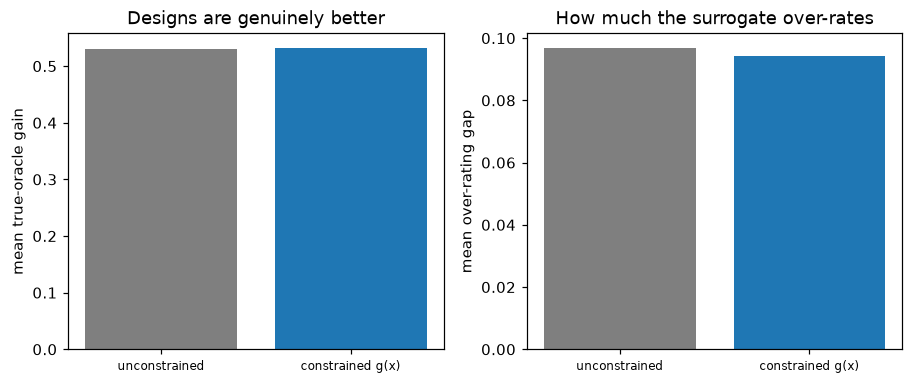

In [10]:
fig, ax = plt.subplots(1,2,figsize=(8.4,3.6))
labels=list(rows); x=np.arange(len(labels))
ax[0].bar(x,[rows[l][0] for l in labels],color=["#7F7F7F","#1F77B4"]); ax[0].set_xticks(x); ax[0].set_xticklabels(labels,fontsize=8)
ax[0].set_ylabel("mean true-oracle gain"); ax[0].set_title("Designs are genuinely better")
ax[1].bar(x,[rows[l][1] for l in labels],color=["#7F7F7F","#1F77B4"]); ax[1].set_xticks(x); ax[1].set_xticklabels(labels,fontsize=8)
ax[1].set_ylabel("mean over-rating gap"); ax[1].set_title("How much the surrogate over-rates")
fig.tight_layout(); plt.show()

## Summary

This notebook ran the full Attack-as-Design loop on TF-Bind-8:

**sequence → features → surrogate → GA attack (with iterations) → independent verification.**

The exact 65,536-mer oracle is the ground-truth verifier the surrogate never fully saw; a disjoint held-out
surrogate is a second independent check. Swap `FEAT` between `"onehot"` and `"kmer4"` to confirm the
featurization is interchangeable. The biological rule `g(x)` keeps designs realistic without training any
extra model.

Paper + code: **github.com/armandyam/attack-as-design**
